In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

2026-05-07 10:39:10.974282: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778150351.005166     451 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778150351.014146     451 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778150351.037255     451 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778150351.037293     451 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778150351.037296     451 computation_placer.cc:177] computation placer alr

In [2]:
data = pd.read_csv(
    "/kaggle/input/datasets/nimishagrawal17/electric-production/Electric_Production.csv"
)

In [3]:
data['Value'] = pd.to_numeric(data['Value'])

In [4]:
values = data['Value'].values.reshape(-1,1)

In [5]:
scaler = MinMaxScaler()

In [6]:
scaled_data = scaler.fit_transform(values)

In [7]:
sequence_length = 12

x = []
y = []

In [8]:
for i in range(sequence_length,len(scaled_data)):
    
    x.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

x = np.array(x)
y = np.array(y)

In [9]:
train_size = int(len(x)*0.8)


In [10]:
x_train = x[:train_size]
y_train = y[:train_size]

x_test = x[train_size:]
y_test = y[train_size:]


In [11]:
model = Sequential()

model.add(
    SimpleRNN(
        64,
        activation='tanh',
        input_shape=(x_train.shape[1],1)
    )
)

model.add(Dense(32,activation='relu'))

model.add(Dense(1))


2026-05-07 10:39:18.439502: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [14]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [15]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test,y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop,reduce_lr]
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0964 - mae: 0.2280 - val_loss: 0.0060 - val_mae: 0.0561 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0063 - mae: 0.0647 - val_loss: 0.0066 - val_mae: 0.0655 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - mae: 0.0466 - val_loss: 0.0032 - val_mae: 0.0408 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024 - mae: 0.0379 - val_loss: 0.0031 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - mae: 0.0352 - val_loss: 0.0031 - val_mae: 0.0382 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 - mae: 0.0305 - val_loss: 0.0036 - val_mae: 0.0410 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - mae: 0.0306 - val_loss: 0.0028 - val_mae: 0.0361 - learning_rate: 0.0010
Epoch 8/100


In [16]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [17]:
y_test_actual = scaler.inverse_transform(y_test)


In [18]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)
mae = mean_absolute_error(
    y_test_actual,
    predictions
)

r2 = r2_score(
    y_test_actual,
    predictions
)

In [19]:
accuracy = r2 * 100

In [20]:
print("RMSE :",rmse)
print("MAE :",mae)
print("R2 Score :",r2)
print("Accuracy :",accuracy)

RMSE : 3.7016756734017044
MAE : 2.6211094363522216
R2 Score : 0.8503397157960622
Accuracy : 85.03397157960622


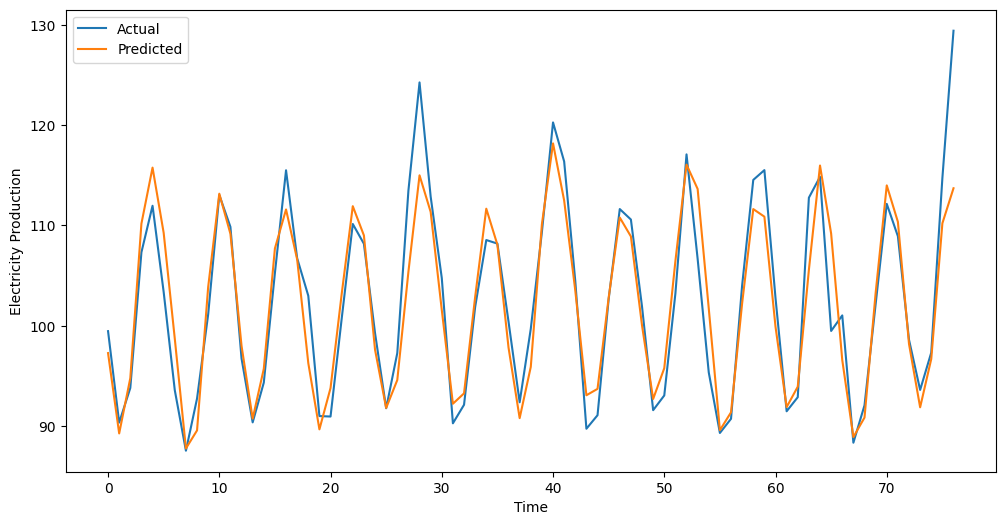

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.xlabel("Time")
plt.ylabel("Electricity Production")

plt.legend()

plt.show()